In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

- **단계 3: 메모리 추가** — 체크포인트, Thread ID (장단기메모리) ★★★★★
- **단계 4: Human-in-the-Loop** — interrupt, 승인 흐름 ★★★★★

# 1.reducer(리듀서)
줄이기 라는 뜻으로, 합치는 개념(덮어쓰기가 아닌 추가). 파이썬 개념이랑 다르다. 

add_messages로 합치면,
```python
a = ["포도", "딸기"] 에다가
a = ["사과"] 를 add_messages
a = ["포도", "딸기", "사과"]
```
일반 파이썬이라면 a=["사과"]

reducer때문에 들어가지 않아도 되는 코드
```python
msgs = state["messages"] 
msgs.append(response)
```

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

graph_builder

### 챗봇 노드

- 인자를 3가지 방법으로 만들 수 있다.
1. state: in - state: out

```python
return State(messages=[response])
```
2. dict 방식
```python
return {"messages": [response]}
```

In [3]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

def chatbot(state:State): # State in
    response = llm.invoke(state["messages"])   

    return {"messages": [response]} # State out


In [4]:
# 노드 정의
graph_builder.add_node("chatbot", chatbot)

In [5]:
# 진입점 및 종료점
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [6]:
# 그래프 컴파일
graph = graph_builder.compile()

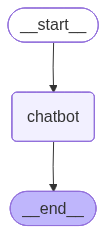

In [7]:
graph

### 왜 HumanMessage로 사용하는가?

기본적으로, dictionary로 설정이 되어 있어야 한다.

랭그래프는 state in - state out인데, state자체가 dictionary이기 때문이다.

### 어떤 dict 이어야해?
State를 넣어줄건데 내가 지정한 key에 넣는데, 이 key의 타입을 봐야 하는것이다. int냐 str이냐 list냐 이것이 문제. 

앞에 State에서 messages의 타입을 list로 줬기 때문에, 따라서 list로 넣어주는것이다.

왜 list냐?? add_message reducer를 통해 대화들을 리스트로 정리를 하기 위함이다(누적).

list에 들어가야 하는것은 langchain의 message type이다. llm의 invoke를 수행하려면 message type 객체 이어야 한다.

HumanMessage, AIMessage, SystemMessage 3가지의 message type이다.

### RunnalbeConfig

- recursion_limit: 노드를 몇바퀴 돌지에 대한 제한.

- thread_id: 단기 메모리를 위함. 채팅 세션 즉, 채팅방 아이디

In [8]:
import langchain
langchain.__version__

'1.0.1'

In [9]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage

user_input = "안녕하세요! LangGraph에 대해 소개해주세요"

config = RunnableConfig(recursion_limit=20, thread_id=10)

inputs = {
    "messages": [HumanMessage(content=user_input)]
}

stream_graph(graph, inputs=inputs, config=config)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! LangGraph에 대해 소개해드릴게요.

**LangGraph**는 자연어 처리(NLP)와 관련된 작업에서 언어 모델과 그래프 구조를 결합하여 더 효과적인 정보 표현과 추론을 가능하게 하는 기술 또는 프레임워크를 의미합니다. 구체적으로, LangGraph는 텍스트 데이터 내의 개체(entity), 개념(concept), 관계(relationship) 등을 노드와 엣지로 표현하는 그래프를 생성하고, 이를 바탕으로 언어 모델이 더 깊이 있는 이해와 복잡한 질의응답, 지식 추론 등을 수행할 수 있도록 돕습니다.

주요 특징은 다음과 같습니다:

1. **그래프 기반 지식 표현**: 텍스트에서 추출한 정보들을 그래프 형태로 구조화하여, 단순한 텍스트 임베딩보다 더 풍부한 의미 관계를 표현합니다.

2. **복잡한 관계 추론**: 그래프 구조를 활용해 여러 개체 간의 복잡한 관계를 탐색하고, 이를 통해 더 정확한 답변이나 예측을 할 수 있습니다.

3. **확장성 및 융합성**: 다양한 데이터 소스에서 추출한 지식을 하나의 그래프로 통합하여, 다중 모달 데이터나 외부 지식과도 연동이 가능합니다.

4. **응용 분야**: 지식 그래프 구축, 질의응답 시스템, 추천 시스템, 문서 요약, 대화형 AI 등 다양한 NLP 응용 분야에 활용됩니다.

만약 특정 LangGraph 프로젝트나 라이브러리, 혹은 서비스에 대해 궁금하신 거라면, 조금 더 구체적으로 알려주시면 상세히 설명해드릴 수 있습니다!

# 2. 도구 정의(tool)

tool은 코딩으로 만들 수 있다는것이 가장 큰 장점

In [10]:
from langchain_core.tools import tool

@tool
def add(a:int, b:int) -> int:
    "add two numbers"
    return a + b

In [11]:
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition

tavily = TavilySearch(max_results=2)
tools = [tavily, add]

print("tavily")
result = tavily.invoke("LangGraph란 무엇인가요?")
print(result)

print("-----------------------")

print("add")
print(add.invoke({"a":1, "b":2}))

tavily
{'query': 'LangGraph란 무엇인가요?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://blog.naver.com/pjt3591oo/223861729229?viewType=pc', 'title': 'langgraph 소개 및 기본개념 : 네이버 블로그', 'content': 'LangGraph는 LangChain 상태계의 일부로 LLM 애플리케이션의 흐름을 그래프로 정의하고 실행하는 라이브러리입니다. 여기서 그래프는 CS(Computer Science)', 'score': 0.9073207, 'raw_content': None}, {'url': 'https://brunch.co.kr/@wikibook/63', 'title': 'LangGraph로 복잡한 AI 워크플로 구현하기', 'content': "brunch LangGraph는 복잡한 AI 워크플로를 그래프 구조로 설계하고 구현할 수 있게 해주는 도구로, 기존 순차적 처리 방식의 한계를 뛰어넘을 수 있습니다. 이런 과정을 그래프로 표현하면 시각적으로 이해하기 쉽고, '답변의 품질이 충분하지 않은 경우 다시 정보를 검색한다'와 같은 조건 분기나 루프 구조도 자연스럽게 구현할 수 있습니다. 예를 들어 답변 생성 노드는 다음과 같이 구현할 수 있습니다. LangGraph는 그래프 구조를 이미지로 시각화할 수 있어 복잡한 워크플로도 한눈에 파악할 수 있습니다. LangGraph는 그래프 구조를 통한 직관적인 워크플로 설계, 강력한 상태 관리, 뛰어난 디버깅 기능까지 - 복잡한 AI 애플리케이션 개발을 위한 모든 것을 갖추고 있습니다. 9장에서는 Q&A 애플리케이션을 직접 구현해보는 실습이, 10장에서는 요구사항 정의서 생성 AI 에이전트 개발 프로젝트가 담겨 있어 실무에 바로 적용할 수 있습니다. brunch membership", 'score': 0.85509074, 'raw

### llm_with_tools

도구 tool_calling이 일어났을때 content에 내용이 없다.

In [12]:
llm_with_tools = llm.bind_tools(tools)

ret1 = llm_with_tools.invoke("LangGraph가 뭐야?")
ret2 = llm_with_tools.invoke("LangGraph가 뭐야? 검색해서 알려줘")
print(ret1)
print("-----------------------")
print(ret2)

content='LangGraph는 언어와 관련된 데이터를 그래프 형태로 시각화하거나 분석하는 도구 또는 플랫폼일 가능성이 큽니다. 하지만 LangGraph라는 용어가 특정한 제품명, 서비스명, 연구 프로젝트명 등으로 다양하게 사용될 수 있어서, 좀 더 구체적인 맥락이나 분야(예: 자연어 처리, 데이터 시각화, 언어 학습 등)를 알려주시면 더 정확한 정보를 제공할 수 있습니다.\n\nLangGraph에 대해 더 구체적인 정보를 원하시나요? 아니면 특정 분야나 용도에 대해 알고 싶으신가요?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 1295, 'total_tokens': 1422, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CY3E4sxIPstF4RmumdHNwfzmdIxRc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--fe93644a-d9fa-4a7b-bbed-6bc2ac52f52a-0' usage_metadata={'input_tokens': 1295, 'output_tokens': 127, 'total_tokens': 1422, 'input_token_de

In [ ]:
print(ret1.content)

LangGraph는 언어와 관련된 데이터를 그래프 형태로 시각화하거나 분석하는 도구 또는 플랫폼일 가능성이 큽니다. 하지만 LangGraph라는 용어가 특정한 제품명, 서비스명, 연구 프로젝트명 등으로 다양하게 사용될 수 있어서, 좀 더 구체적인 맥락이나 분야(예: 자연어 처리, 데이터 시각화, 언어 학습 등)를 알려주시면 더 정확한 정보를 제공할 수 있습니다.

LangGraph에 대해 더 구체적인 정보를 원하시나요? 아니면 특정 분야나 용도에 대해 알고 싶으신가요?


In [ ]:
print(ret2.content)

tool_calls가 두번 들어가는 이유는, openai의 schema와 langchain의 schema 2개인 것이다.

langchain은 사용할 수 있는 모델이 많기 때문에, 하나로 통합하기 위해 하나의 형식으로 통합할 필요가 있는것이다.

In [ ]:
from langchain_teddynote.messages import display_message_tree


display_message_tree(ret2)

    content: ""
    additional_kwargs: {"refusal": None}
    response_metadata:
        token_usage:
            completion_tokens: 17
            prompt_tokens: 1299
            total_tokens: 1316
            completion_tokens_details: {"accepted_prediction_tokens": 0, "audio_tokens": 0, "reasoning_tokens": 0, "rejected_prediction_tokens": 0}
            prompt_tokens_details: {"audio_tokens": 0, "cached_tokens": 1280}
        model_provider: "openai"
        model_name: "gpt-4.1-mini-2025-04-14"
        system_fingerprint: "fp_4c2851f862"
        id: "chatcmpl-CY3E6k7nRYxBEY2oIvC4tEf0D79bL"
        service_tier: "default"
        finish_reason: "tool_calls"
        logprobs: None
    type: "ai"
    name: None
    id: "lc_run--72bcc254-aa44-44bb-af92-904cb462d74e-0"
    tool_calls:
        index [0]
            name: "tavily_search"
            args: {"query": "LangGraph"}
            id: "call_Sr2NJSWDO1yHTgp5vYcvh4fB"
            type: "tool_call"
    invalid_tool_calls:
    usage_m

### react_create_action
1. 어떤 도구를 선택할지 생각, 도구에 넣어줄 query를 지정 
2. action 
3. observation
tool_calling에서 1번이 발생하는것 

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

builder = StateGraph(State)

llm_with_tools = llm.bind_tools(tools)

def chatbot(state:State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools)
builder.add_node("tools", tool_node)

# builder.add_edge(START, "chatbot")
# builder.add_edge("chatbot", END)

### add_conditional_edges
노드이자 일반 함수. 

일반함수란, state-in, state-out이 아니라, 입력값은 state-in이지만, 출력값이 보통 str(문자열)을 뜻하다.


### tools_condition 동작 요약

tools_condition 은 마지막 AI 메시지에 도구 호출이 있는지 확인해 분기한다. 결과는 str(문자열) 이다. 즉 그 문자열 노드에 연결을 해주는 것이다.

결과는 tools나 end가 나오는데, 그에 따라 노드로 분기한다.
- tool_calls 있음 → "tools"
- tool_calls 없음 → "end"
chatbot에 나온 결과는 tools나 end가 나오는데, 그에 따라 노드로 분기한다.

간단한 구현 예시는 아래와 같다.

``` python
def tools_condition(state) -> Literal["tools", "__end__"]:
    # 마지막 메시지 추출
    ai_message = state[-1] if isinstance(state, list) else state["messages"][-1]
    # 분기 판단
    return "tools" if getattr(ai_message, "tool_calls", []) else "__end__"

from typing import Literal

def abc(state) -> Literal["tools", "__end__"]:
    if state["messages"][-1].content == "":
        return "tools"
    else:
        return "__end__"    
```

### llm_with_tools 흐름 (LangGraph 기준, ReAct 관점)

- 도입(의도 인식): 사용자가 “검색해줘”라고 하면, 이는 툴이 필요한 요청으로 인식합니다.
- 조건부 라우팅(TOOL 또는 END): 현재 상태를 보고 다음 노드를 결정합니다.
- 검색 필요 → TOOL 노드로 이동
- 바로 답변 가능 → END 로 이동
- 툴 호출(TOOL 노드): 실제 tool_call을 수행하여 검색 결과(Observation) 를 얻습니다.
- 답변 합성(LLM): Observation을 LLM에 재주입하여 답변을 생성합니다.
- 종료 판단(재라우팅): 생성된 답변이 충분하면 END, 부족하면 다시 TOOL 로 돌아가 추가 검색을 수행합니다.

### ReAct와의 대응
- Thought: 툴 필요성 판단 및 다음 노드 결정
- Action: 툴 호출(tool_call)
- Observation: 툴 결과 수집
- Answer: 답변 생성 → 충분하면 종료(END)

### 2개의 tool일때. 
즉, 모델이 하지 않더라도, 우리가 도구를 쥐어주므로 시키는것이 핵심이다.
1. 검색 / 파일로 저장을 원할 때, 검색 tool과 파일 저장 tool이 두개의 경우, 
2. 챗봇노드에서 tool_calling이 발생해서, tool_node(검색)으로 보내진 후, 검색을 하고 chatbot으로 보내진다.
3. 조건부 노드이기 때문에, 두번째 tool_calling으로 보내진 후, tool_node(파일 저장)으로 보내진 후 다시 chatbot으로 보내진다.
4. 마지막으로 END로 보내진다


tool name과 doc string, description이 주어야 하는게 핵심이다.

tool name, doc string을 아무리 잘 주더라도, 

tool의 호출이 잘 안되는 경우에는, 도구에 붙어있는 system prompt, description을 잘 주는게 핵심이다.

tool_calling이 잘 안되는 오픈소스 llm들이 많다. qwen이 그나마 잘된다.

In [ ]:
builder.add_conditional_edges(
    "chatbot",
    tools_condition, # 사전에 정의된 조건 함수 사용. tools와 end를 반환해준다.
)
# Literal["tools", "__end__"]
# chatbot에 나온 결과는 tools나 end가 나오는데, 그에 따라 노드로 분기한다.

builder.add_edge("tools", "chatbot")

builder.add_edge(START, "chatbot")

graph_with_tools = builder.compile()


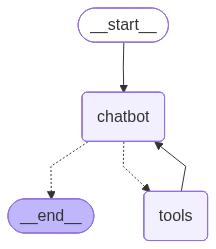

In [ ]:
graph_with_tools

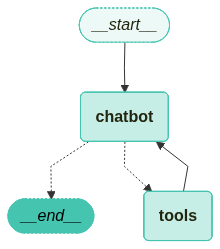

In [ ]:
from langchain_teddynote.graphs import visualize_graph
# 그래프 시각화
visualize_graph(graph_with_tools)

In [ ]:
from langchain_teddynote.messages import stream_graph

# 첫 노드 chatbot이 비어있는 이유는 tool_calling이 일어났기 때문에 비어있다.
stream_graph(graph_with_tools, 
    inputs={"messages": [HumanMessage(content="2025년 LangGraph 사용 사례들을 알려주세요")]},
    config=config)



🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "2025년 LangGraph 사용 사례", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=edsshVochqM", "title": "Building an Agentic AI System Using #LangGraph ... - YouTube", "content": "#LangGraph 를 활용한 Agentic AI 시스템 구축 (에이전틱AI 밋업 2025 Q1)\n테디노트 TeddyNote\n48000 subscribers\n513 likes\n15820 views\n6 Mar 2025\n본 내용은 2025년 3월4일 진행한 에이전틱AI 밋업 2025 Q1 에서 진행한 발표 내용입니다.\n\n✅ 발표자료 링크: https://linktr.ee/teddynote\n✅ 핸즈온 튜토리얼 링크: https://link.teddynote.com/MEETUP\n\n📘 랭체인 튜토리얼 무료 전자책(wikidocs)\nhttps://wikidocs.net/book/14314\n\n✅ 랭체인 한국어 튜토리얼 코드저장소(GitHub)\nhttps://github.com/teddylee777/langchain-kr\n\n⭐️ 패스트캠퍼스 RAG 비법노트 ⭐️\n- 강의링크: https://bit.ly/3WJQjtf\n- 분량: 약 70시간\n\n#agent \n---\n📍 \"테디노트의 RAG 비법노트\" 랭체인 강의: https://fastcampus.co.kr/data_online_teddy\n📘 랭체인 한국어 튜토리얼(무료 전자책): https://wikidoc

# 3. 메모리

장기메모리 어렵다! 하지만 반드시 알아야 한다. 트랜드 자체가 장기메모리를 잘하자

공손하게 해줘 -> 기억해줘 이것이 trigger word. 모델이 사용자가 공손하게 해달라는것을 장기메모리에 업데이트를 하고, 그다음에는 무조건 공손하게 답한다는 것이다.

## 목적
세션 간에도 사용자 정보를 유지하는 **영구 상태 관리**를 추가한다.

### 핵심 개념
- **Checkpointer**: 대화 상태 저장/복원
- **Thread ID**: 세션 식별자
- **Persistent State**: 누적 이력 기반 컨텍스트

### 단기메모리
- 랭그래프에선 너무 쉽다
- thread_id (채팅방)별로 관리
- 즉 멀티턴에 사용

### 장기메모리
- pc를 껏다가 켜도 유지되는것이 장기 메모리.
- 피드백이 쥐어주면, 그게 장기메모리에 반영이 되면 답변스타일, 취향정보, 좋아하는 정보 직업들을 기억해준다.
- thread_id가 달라져도 기억을 하고 답장을 한다.
- 채팅세션이 달라져도 기억함.
- trigger word가 있으면 저장한다 "remember" 예를들면, 키워드




### call_model

state in, state output에 config와 sotre가 필요하다. 여기에다가 실제로 disk에다가 저장을 해준다. 이때 pc를 껐다 켜도, 메모리를 저장할 수 있다는 것이다. 이 store를 넘겨줘야 한다는 것이다.

데이터베이스인 postgres, 인메모리등을 사용할 수 있으며 sotre에다가 장기 기억을 key-value 쌍으로 저장하는 것이다. 그럼 여기에 아이덴티티가 들어간다.

아이덴티티란? 모든걸 저장하는게 아니라, 기억해줬으면 하는 정보들을 추출을 해서 키벨류 쌍으로 저장하는 것이다.

실제로는 postgress saver를 사용한다.

1:17:15 invoke로 메시지를 가져와서, put으로 키와 벨류쌍으로 딕셔너리를 저장하는 것이다. 이것을 sql로 저장한다.

즉 키 정의가 제일 중요하다. 키로 정의하기 어려운 맥락정인 정보는, SQL로 문맥에 따라서 저장하기도 한다. 

오픈 프롬프트는로 인메모리를 저장할 때, 여러가지를 저장하는데, 대규모 서비스를 하는데 이것을 수정할 필요가 있다는것을 알아야 한다.

### 단기메모리



### react_create_action
1. 어떤 도구를 선택할지 생각, 도구에 넣어줄 query를 지정 
2. action 
3. observation
tool_calling에서 1번이 발생하는것 


###장기 기억 저장: `remember` 키워드

메시지에 `remember` 가 포함되면 중요 정보를 장기 저장소에 기록합니다.

- **예시**: "내 이름은 재호야 remember"  
- **저장 대상**: 이름, 직업, 선호 등 사용자 프로필성 정보  
- **기본 원칙**: 일반 대화는 단기 컨텍스트로만 유지

In [ ]:
# 여기서 get_format_instructions()는 langchain의 PydanticOutputParser 안에 있는 메서드.
# Langchain 공식 docs 기준(get_format_instructions() reference: https://python.langchain.com/v0.1/docs/modules/model_io/output_parsers/pydantic/)
# 이 메서드는 파싱되는 결과가 어떤 포맷이어야 하는지 LLM에게 지시하는 텍스트 설명(string)을 반환.
# 즉 LLM이 출력할 JSON 형식 예시나 필드 설명 등 주요 ‘형식 안내’를 돌려주는 역할..
# 아래처럼 사용하면 프롬프트 내에 해당 형식 안내 문구가 삽입됨.
# format_instructions는 prompt에 삽입되어, LLM이 메모리 추출 결과를 어떤 형식(예: JSON, 필드명, 예시 등)으로 출력해야 하는지 안내하는 역할을 해.
# memory_parser.get_format_instructions()에서 반환되는 값은 memory_parser가 파싱할 수 있도록 필요한 형식 정보를 설명하는 string.
# 즉, prompt 안에 이 값을 넣어 LLM이 알맞게 출력하도록 유도하고, 이후엔 memory_parser가 그 형식에 맞춰 출력 내용을 파싱하는 흐름.

In [ ]:
from datetime import datetime
from typing import List, TypedDict
from pydantic import Field, BaseModel

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import PydanticOutputParser

# Pydantic 모델 정의
class MemoryItem(BaseModel):
    importance: int = Field(description="중요도 (1-5, 5가 가장 중요)", ge=1, le=5)
    confidence: float = Field(description="추출 신뢰도(0.0-1.0)", ge=0.0, le=1.0)

# ExtractedMemories = 장기 메모리로 저장할 데이터를 구조화하는 모델
class ExtractedMemories(BaseModel):
    """Extracted Memory Collection"""
    memories: List[MemoryItem] = Field(description="추출된 메모리 아이템 리스트")
    summary: str = Field(description="대화 내용 요약")
    timestamp: str = Field(
        default_factory=lambda: datetime.now().isoformat(), description="추출 시간"
    )

DEFAUOT_SYSTEM_PROMPT = """
You are an expert memory extraction assistant. 
Your task is to extract important information from user conversations and convert them into structured key-value pairs for long-term memory storage.

Extract ALL relevant information from the conversation, including:
- Personal information (name, age, location, occupation, etc.)
- Preferences and interests
- Relationships and social connections
- Important facts or events mentioned
- Opinions and beliefs
- Goals and aspirations
- Any other notable information

For each piece of information:
1. Create a concise, searchable key
2. Store the complete value
3. Categorize appropriately
4. Assess importance (1-5 scale)
5. Evaluate extraction confidence (0.0-1.0)
"""

# Memory Extracter
def create_memory_extractor(model, system_prompt):
    """
    메모리 추출기 생성
    Args:
        model: 사용할 언어 모델. None일 경우 기본 ChatOpenAI 모델 사용
        system_prompt: 시스템 프롬프트. None일 경우 기본 프롬프트 사용

    Returns:
        메모리 추출 체인
    """

    memory_parser = PydanticOutputParser(pydantic_object=ExtractedMemories)

    if system_prompt is None:
        system_prompt = DEFAUOT_SYSTEM_PROMPT

    template = f"""{system_prompt}

User Input: {{input}}

{{format_instructions}}

Remember to:
- Extract multiple memory items if the conversation contains various pieces of information
- Use clear, consistent key naming conventions
- Preserve context in values when necessary
- Be comprehensive but avoid redundancy
"""

    prompt = ChatPromptTemplate.from_template(
        template,
        partial_variables={
            "format_instructions": memory_parser.get_format_instructions()
        }
    )

    model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

    memory_extractor = prompt | model | memory_parser

    return memory_extractor

### 장기 메모리를 위한 대화 시스템

from langgraph.graph import MessagesState
````
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
````

In [ ]:
# 위에 있는것들을 불러와서 사용할 수 있다.
from langchain_teddynote.memory import create_memory_extractor

from typing import Any
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.store.base import BaseStore
from langchain_openai import ChatOpenAI

import uuid

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
memory_extractor = create_memory_extractor(model="gpt-4.1-mini")

#*는 언팩 연산자가 아니라 "keyword-only 파라미터"를 지정하는 구문.

def call_model(
    state: MessagesState,
    config: RunnableConfig,
    *, #*는 언팩 연산자가 아니라 "keyword-only 파라미터"를 지정하는 구문.
    store: BaseStore
):

    """Call the LLM model and manage user memory.

    Args:
        state (MessagesState): The current state containing messages.
        config (RunnableConfig): The runnable configuration.
        store (BaseStore): The memory store.
    """

    # user_id 추출
    # user_id를 config에서 받아서, memories의 하위폴더에 저장하는것.
    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id) 

    print(namespace)

    # 유저의 메모리 검색
    memories = store.search(namespace, query=str(state["messages"][-1])) # 해당 memories/user_id공간에서 연관된 기억(메모리)들을 불러온다.
    info = '\n'.join([f"{memory.key}: {memory.value}" for memory in memories]) # memories에서 꺼내온 정보를 포맷팅
    system_msg = f"You are a helpful assistant talking to the user. User info: {info}"

    # 사용자가 기억 요청 시 메모리 저장. (remember 입력)
    last_message = state["messages"][-1]
    if "remember" in last_message.content.lower():
        result = memory_extractor.invoke({"input": str(state["messages"][-1].content)})
        for memory in result.memories:
            print(memory)
            print("-" * 100)
            store.put(namespace, str(uuid.uuid4()), {memory.key: memory.value})

    response = model.invoke(
        [{"role": "system", "content": system_msg}] + state["messages"]
    )
    return {"messages": response}


In [ ]:
from langgraph.graph import MessagesState, START
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

memory_saver = InMemorySaver()
memory_store = InMemoryStore()

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
graph_with_memory = builder.compile(
    checkpointer=memory_saver,
    store=memory_store
)

In [47]:
from langchain_teddynote.messages import stream_graph


def run_graph(
    msg,
    thread_id="default",
    user_id="default",
):
    config = {
        "configurable": {
            "thread_id": thread_id + user_id,
            "user_id": user_id,
        }
    }
    print(f"\n[유저🙋] {msg}")
    stream_graph(
        graph_with_memory,
        inputs={"messages": [{"role": "user", "content": msg}]},
        config=config,
    )
    print()

In [ ]:
# 메시지, thread_id, user_id 전달 / thread_id는 방 이름이고, user_id는 로그인 아이디라고 생각
run_graph("안녕? 내 이름은 재호야", "1", "someone")


[유저🙋] 안녕? 내 이름은 재호야
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕 재호야! 만나서 반가워. 어떻게 도와줄까?


In [49]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "1", "someone")


[유저🙋] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네 이름은 재호라고 했어! 맞아?


In [50]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "2", "someone")


[유저🙋] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
죄송하지만, 사용자의 이름을 알 수 없습니다. 이름을 알려주시면 기억할 수 있어요!


### Thread 간 지속성

사용자 기반 장기 기억은 Thread 가 달라도 유지됩니다.

- **Short-term Memory**: Thread 컨텍스트(세션 단위)
- **Long-term Memory**: User ID 기반 프로필(세션 간 유지)

실무에서도 사용자 정보는 클라이언트가 달라도 유지되는 것이 일반적입니다.

In [51]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고 했더라?", "1004", "someone")


[유저🙋] 내 이름이 뭐라고 했더라?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
죄송하지만, 사용자의 이름을 기억하지 못해요. 다시 알려주시면 기억하는 데 도움이 될 수 있어요!


In [52]:
# 메시지, thread_id, user_id 전달
run_graph(
    "내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember", "4", "someone"
)


[유저🙋] 내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "occupation",
      "value": "AI Engineer",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    },
    {
      "key": "hobby",
      "value": "Netflix 보기",
      "category": "preference",
      "importance": 4,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 자신의 직업이 AI Engineer이며, 취미는 Netflix 보기라고 밝혔다.",
  "timestamp": "2024-06-13T00:00:00Z"
}key='occupation' value='AI Engineer' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
key='hobby' value='Netflix 보기' category='preference' importance=4 confidence=1.0
----------------------------------------------------------------------------------------------------
알겠습니다! 당신의 직업은 AI 엔지니어이고, 취미는 넷플릭스 보기입니다. 필요할 때 언제든

In [53]:
# 다른 스레드에서 실행
run_graph("내 이름, 직업, 취미 알려줘", "100", "someone")


[유저🙋] 내 이름, 직업, 취미 알려줘
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! 제가 알고 있는 정보에 따르면,

- 이름은 알려주지 않으셨어요.
- 직업은 AI 엔지니어이시고,
- 취미는 Netflix 보기라고 하셨습니다.

더 궁금한 점 있으면 말씀해 주세요!


In [54]:
# 다른 user_id 로 실행한 경우
run_graph("내 이름, 직업, 취미 알려줘", "100", "other")


[유저🙋] 내 이름, 직업, 취미 알려줘
('memories', 'other')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! 죄송하지만, 사용자의 이름, 직업, 취미에 대한 정보는 제가 알 수 없어요. 알려주시면 기억하고 대화에 반영할 수 있습니다. 알려주실래요?


### State 확인

현재 저장된 상태를 조회해 메시지 이력과 체크포인트 정보를 확인합니다.

- **메시지 수**  
- **체크포인트 ID**  
- **최근 메시지 내용**

상태 조회는 디버깅과 검증에 유용합니다.

In [55]:
# 임의의 Config 설정
config = {
    "configurable": {
        "thread_id": "100" + "someone",
        "user_id": "someone",
    }
}

# 현재 상태 가져오기
snapshot = graph_with_memory.get_state(config)

print("📊 현재 상태 정보:")
print(f"- 메시지 수: {len(snapshot.values['messages'])}개")
print(f"- 체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")

# 최근 메시지 몇 개 표시
print("\n[최근 메시지]")
for msg in snapshot.values["messages"]:
    role = msg.type if hasattr(msg, "type") else "unknown"
    content = msg.content if hasattr(msg, "content") else str(msg)
    print(f"  [{role}]: {content}")

📊 현재 상태 정보:
- 메시지 수: 2개
- 체크포인트 ID: 1f0b94f9-f215-6bfc-8001-2a357592b99c

[최근 메시지]
  [human]: 내 이름, 직업, 취미 알려줘
  [ai]: 안녕하세요! 제가 알고 있는 정보에 따르면,

- 이름은 알려주지 않으셨어요.
- 직업은 AI 엔지니어이시고,
- 취미는 Netflix 보기라고 하셨습니다.

더 궁금한 점 있으면 말씀해 주세요!


# 4. Human in the loop(HITL)

Agent 서비스를 구현할 때 정말 많이 쓴다.

Human in the loop이 없다면 결과물의 책임을 모두다 진다는 것이다.

리포트를 작성하고 HITL을 줘서 검수를 한다. - 이대로 진행할까요?

입력을 주면, human response에 저장하는 식이다. 이 HITL도 tool_callings가 발생하는 것이다.

메이저 챗봇(chatgpt, claude, gemini, perplexity)에서 자주 사용

예) slack, notion에서 interrupt응답을 받아서 게재하는 식. 

사용자의 다른 의견을 받을 수 있다는것은 큰 장점

### 기대효과
- 안정성 향상, 신뢰성 확보, 협업 강화, 정책 준수

### HITL 그래프 구성

`human_assistance` 도구를 통해 승인 지점을 구현
- 역할: 필요시 interrupt로 중단 후 인간 답변 대기
- 흐름: chatbpt -> tools(human_assistance) -> chatbot -> END
- 주의: interrupt와 병렬 도구 호출은 함께 사용하지 않는다.(재개 시 중복 호출 방지)

In [ ]:
from langchain_core.tools import tool
from langgraph.types import Command, interrupt

@tool
def human_assistance(query:str) -> str:
    """Request assistance from an expoert(human)"""

    human_response = interrupt({"query": query})

    return human_response["data"]

# 5. 상태 커스터마이징





### 상태 업데이트 도구

이메일 작성기를 만드는데, 이 초안이 맘에 안들 수 있다. 이때 피드백을 하면 그 방향에 맞게 피드백 할 수 있다. 
tool_callings는 답변 내기 전에 프롬프트가 조절하는 것이다.

### 커스텀 상태 테스트

# 6. 상태 이력 관리

체크포인트 기반으로 상태를 저장/복원해 롤백/재실행 시나리오를 실습.

실험할 때 쓰면 좋다.

### 핵심개념
- State History: 상태 변경 이력 관리(추적/ 복원)
- Checkpoint ID: 특정 시점 식별자
- Rollback: 특정 시점으로 복원
- Resume: 복원 상태에서 재실행


### 기대효과
- 안전한 실험, 디버깅 효율, A/B테스트, 안전성 향상


이력 조회: get_state_history

In [ ]:
graph_builder = StateGraph(State)

tools = [TavilySearch(max_results=2)]
llm_with_tools_tt = llm.bind_tools(tools)

def chatbot_tt(state: State):
    """상태 관리용 챗봇"""
    return {"messages": [llm_with_tools_tt.invoke(state["messages"])]}

# 그래프 구성
graph_builder.add_node("chatbot", chatbot_tt)
tool_node_tt = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node_tt)

graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")

In [ ]:
# ### Azure OpenAI
# from langchain_azure_ai import AzureOpenAI
# import os

# azure_model = AzureOpenAI(
#     deployment_name="gpt-4.1-mini", # 사용하는 모델명
#     api_version="2024-12-01-preview",
#     azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
#     api_key=os.environ["AZURE_OPENAI_API_KEY"],    
# )